# Exploratory Data Analysis


--- Analisis Skewness (Kemiringan) Fitur ---
chlorides                6.079625
residual sugar           4.527907
sulphates                2.398022
bound_sulfur_dioxide     1.926232
total sulfur dioxide     1.460665
free sulfur dioxide      1.201965
fixed acidity            1.088465
total_acidity            1.064862
alcohol_density_ratio    0.832269
alcohol                  0.821407
volatile acidity         0.669090
citric acid              0.381718
pH                       0.115447
density                  0.083304
dtype: float64


/tmp/ipykernel_16/2758111541.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='quality', data=df_train, palette='viridis')


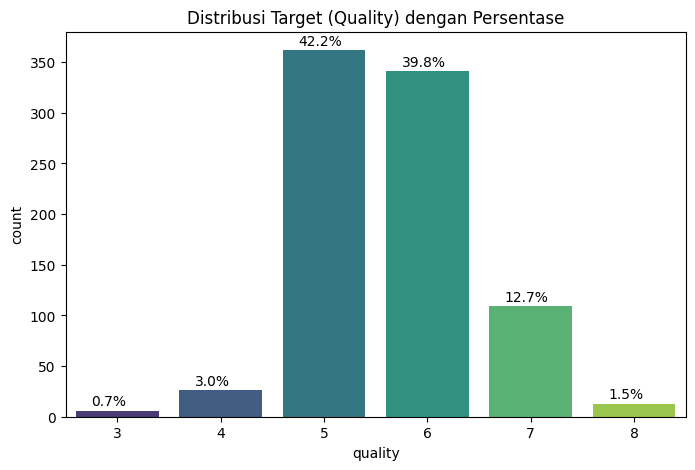

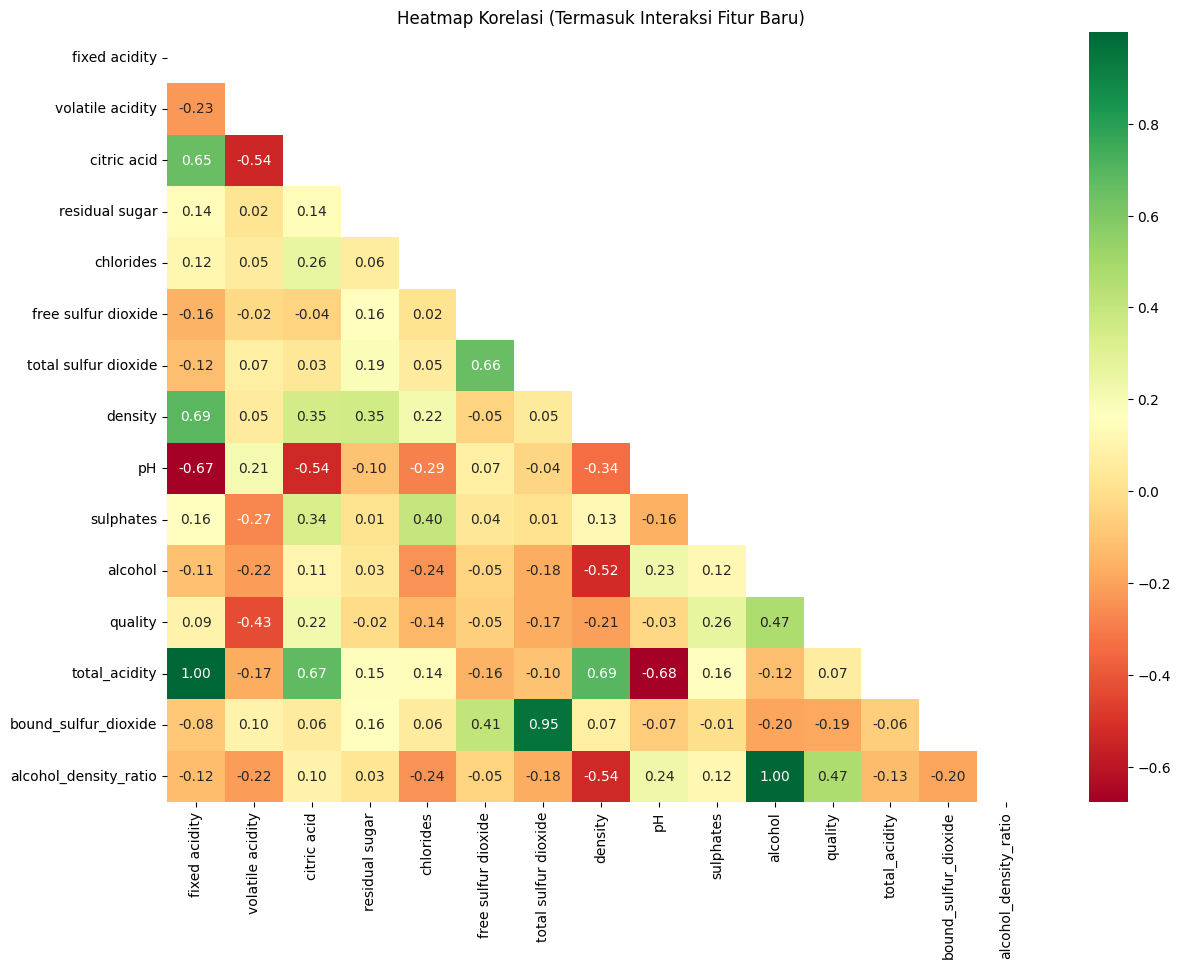

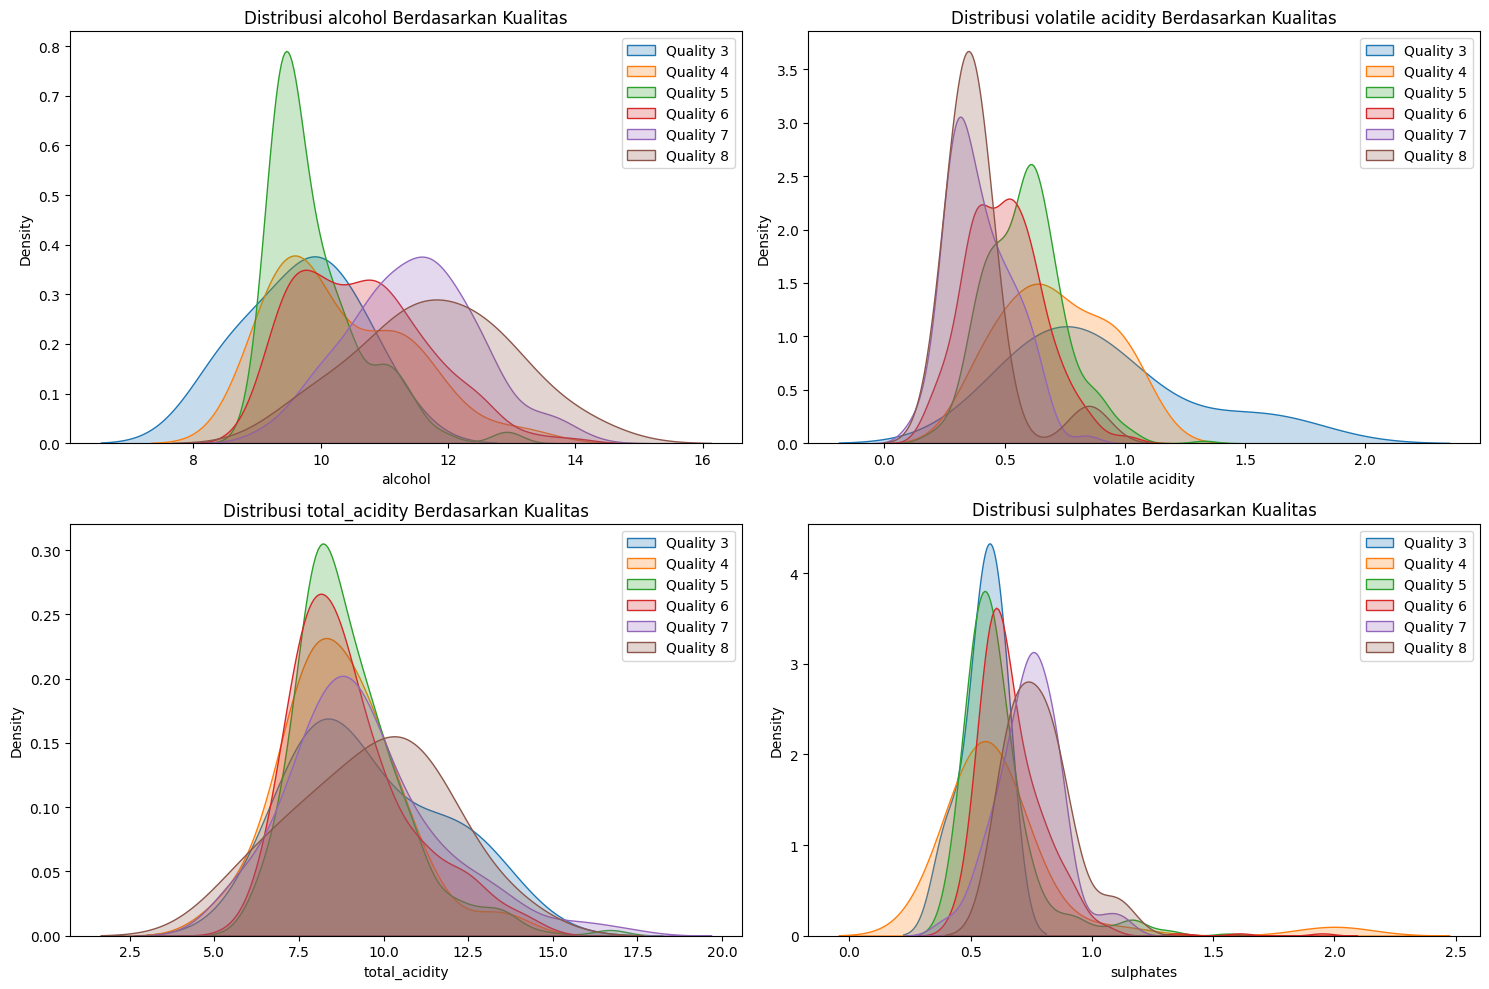

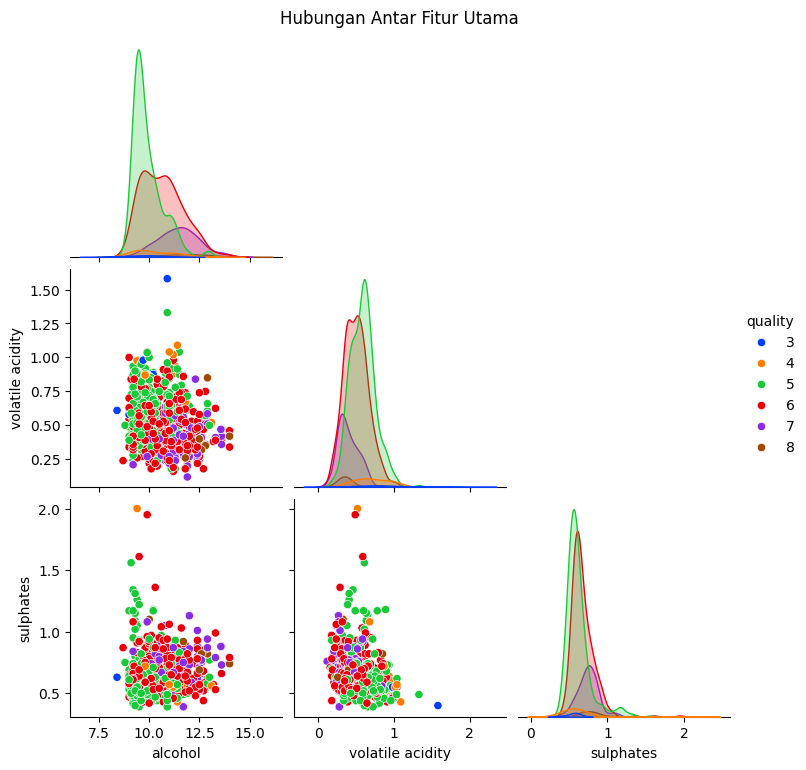


--- Persentase Outlier Per Fitur (IQR Method) ---
fixed acidity: 30 outlier (3.50%)
volatile acidity: 8 outlier (0.93%)
citric acid: 1 outlier (0.12%)
residual sugar: 76 outlier (8.87%)
chlorides: 59 outlier (6.88%)
free sulfur dioxide: 15 outlier (1.75%)
total sulfur dioxide: 19 outlier (2.22%)
density: 25 outlier (2.92%)
pH: 14 outlier (1.63%)
sulphates: 31 outlier (3.62%)
alcohol: 9 outlier (1.05%)
total_acidity: 37 outlier (4.32%)
bound_sulfur_dioxide: 54 outlier (6.30%)
alcohol_density_ratio: 9 outlier (1.05%)


In [1]:
# =================================================================
# Tahap 1: Exploratory Data Analysis (EDA) - Ditingkatkan
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# Nama: Dimas Pasha Akrilian
# =================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew

# 1.1 Memuat Dataset
train_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_training.csv'
test_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_testing.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# -----------------------------------------------------------------
# PENGEMBANGAN FITUR AWAL (Feature Engineering for EDA)
# Membuat fitur interaksi untuk melihat pengaruhnya di Heatmap
# -----------------------------------------------------------------
df_train['total_acidity'] = df_train['fixed acidity'] + df_train['volatile acidity'] + df_train['citric acid']
df_train['bound_sulfur_dioxide'] = df_train['total sulfur dioxide'] - df_train['free sulfur dioxide']
df_train['alcohol_density_ratio'] = df_train['alcohol'] / df_train['density']

# 1.2 Ringkasan Statistik & Skewness
print("\n--- Analisis Skewness (Kemiringan) Fitur ---")
# Mengecek skewness untuk menentukan kebutuhan PowerTransformer nanti
numeric_features = df_train.drop(columns=['Id', 'quality']).columns
skewness = df_train[numeric_features].apply(lambda x: skew(x)).sort_values(ascending=False)
print(skewness)

# 1.3 Visualisasi Target dengan Persentase
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='quality', data=df_train, palette='viridis')
total = len(df_train['quality'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    ax.annotate(percentage, (p.get_x() + 0.15, p.get_height() + 5))
plt.title('Distribusi Target (Quality) dengan Persentase')
plt.show()

# 1.4 Heatmap Korelasi Ditingkatkan
# Menyertakan fitur baru untuk melihat apakah interaksi lebih kuat dari fitur asli
plt.figure(figsize=(14, 10))
correlation_matrix = df_train.drop(columns=['Id']).corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Menyembunyikan duplikasi diagonal
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Heatmap Korelasi (Termasuk Interaksi Fitur Baru)')
plt.show()

# 1.5 Analisis Separabilitas (KDE Plot)
# Melihat fitur mana yang paling mampu membedakan antar kelas kualitas
key_features = ['alcohol', 'volatile acidity', 'total_acidity', 'sulphates']
plt.figure(figsize=(15, 10))
for i, col in enumerate(key_features):
    plt.subplot(2, 2, i+1)
    for q in sorted(df_train['quality'].unique()):
        sns.kdeplot(df_train[df_train['quality']==q][col], label=f'Quality {q}', fill=True)
    plt.title(f'Distribusi {col} Berdasarkan Kualitas')
    plt.legend()
plt.tight_layout()
plt.show()

# 1.6 Multivariate Analysis (Pairplot)
# Menganalisis hubungan 3 fitur teratas secara simultan
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'quality']
sns.pairplot(df_train[top_features], hue='quality', palette='bright', corner=True)
plt.suptitle('Hubungan Antar Fitur Utama', y=1.02)
plt.show()

# 1.7 Identifikasi Persentase Outlier Secara Statistik
print("\n--- Persentase Outlier Per Fitur (IQR Method) ---")
for col in numeric_features:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_train[col] < (Q1 - 1.5 * IQR)) | (df_train[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outlier ({(outliers/total*100):.2f}%)")

# Data Preparation

In [2]:
# =================================================================
# Tahap 2: Data Preparation (Ditingkatkan)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from imblearn.over_sampling import SMOTE
import pandas as pd

# 2.1 Feature Engineering (Formalisasi dari tahap EDA)
# Kita buat fitur baru yang terbukti memiliki korelasi kuat di tahap EDA
def add_features(df):
    df_new = df.copy()
    df_new['total_acidity'] = df_new['fixed acidity'] + df_new['volatile acidity'] + df_new['citric acid']
    df_new['bound_sulfur_dioxide'] = df_new['total sulfur dioxide'] - df_new['free sulfur dioxide']
    df_new['alcohol_density_ratio'] = df_new['alcohol'] / df_new['density']
    return df_new

df_train_eng = add_features(df_train)
df_test_eng = add_features(df_test)

# Memisahkan fitur dan target
X = df_train_eng.drop(columns=['Id', 'quality'])
y = df_train_eng['quality']
X_test_final = df_test_eng.drop(columns=['Id'])
test_id = df_test_eng['Id']

# 2.2 Split Data Awal (Internal Validation)
# Lakukan split sebelum transformasi untuk mencegah data leakage
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.3 Power Transformation (Yeo-Johnson)
# PowerTransformer menangani skewness dan melakukan scaling sekaligus.
# Ini jauh lebih efektif dibanding StandardScaler untuk data kimiawi yang miring.
pt = PowerTransformer(method='yeo-johnson')

X_train_scaled = pt.fit_transform(X_train_raw)
X_val_scaled = pt.transform(X_val_raw)
X_test_scaled = pt.transform(X_test_final)

# Konversi kembali ke DataFrame untuk kemudahan analisis
X_train_prepared = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_prepared = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_prepared = pd.DataFrame(X_test_scaled, columns=X.columns)

# 2.4 Menangani Class Imbalance dengan SMOTE
# Berdasarkan EDA, kelas 3 dan 8 sangat sedikit sehingga model sulit belajar.
# SMOTE akan menciptakan data sintetis agar model lebih pintar mengenali kelas minoritas.

# k_neighbors=1 karena sampel pada kualitas 3 mungkin sangat sedikit
smote = SMOTE(random_state=42, k_neighbors=1) 
X_train_final, y_train_final = smote.fit_resample(X_train_prepared, y_train)

print(f"--- Ringkasan Data Preparation ---")
print(f"Jumlah fitur digunakan: {X_train_final.shape[1]}")
print(f"Data awal: {len(y_train)} sampel")
print(f"Data setelah SMOTE (Oversampling): {len(y_train_final)} sampel")
print(f"Distribusi kelas setelah SMOTE:\n{y_train_final.value_counts().sort_index()}")

# Verifikasi hasil scaling/transformation
display(X_train_final.head())

--- Ringkasan Data Preparation ---
Jumlah fitur digunakan: 14
Data awal: 685 sampel
Data setelah SMOTE (Oversampling): 1734 sampel
Distribusi kelas setelah SMOTE:
quality
3    289
4    289
5    289
6    289
7    289
8    289
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,total_acidity,bound_sulfur_dioxide,alcohol_density_ratio
0,0.604634,1.377894,-0.042925,-1.174962,-0.033063,-0.420910,-0.816411,0.144651,-0.146500,0.352995,-0.244168,0.699509,-0.839226,-0.241974
1,-0.569616,1.110071,-1.190292,1.905588,0.336465,-1.600988,-1.685685,-0.235261,0.655032,-2.756277,0.658232,-0.541769,-1.405530,0.659507
2,-0.195547,-0.109587,0.063430,-0.635971,-0.934864,-0.568627,-0.270183,-0.024113,0.522486,0.133287,-0.775650,-0.205836,0.023491,-0.764592
3,0.009270,-0.797989,0.924639,-0.635971,0.808160,-1.108916,-1.275308,-0.552383,-0.079125,0.133287,1.030665,0.033154,-1.091075,1.032615
4,-0.414736,0.393348,-1.541804,-0.406668,-0.808685,-0.908930,-1.685685,-0.541805,0.918896,-0.369020,0.962060,-0.538046,-2.090903,0.964710


# Feature Engineering

--- Memulai Recursive Feature Elimination (RFECV) ---


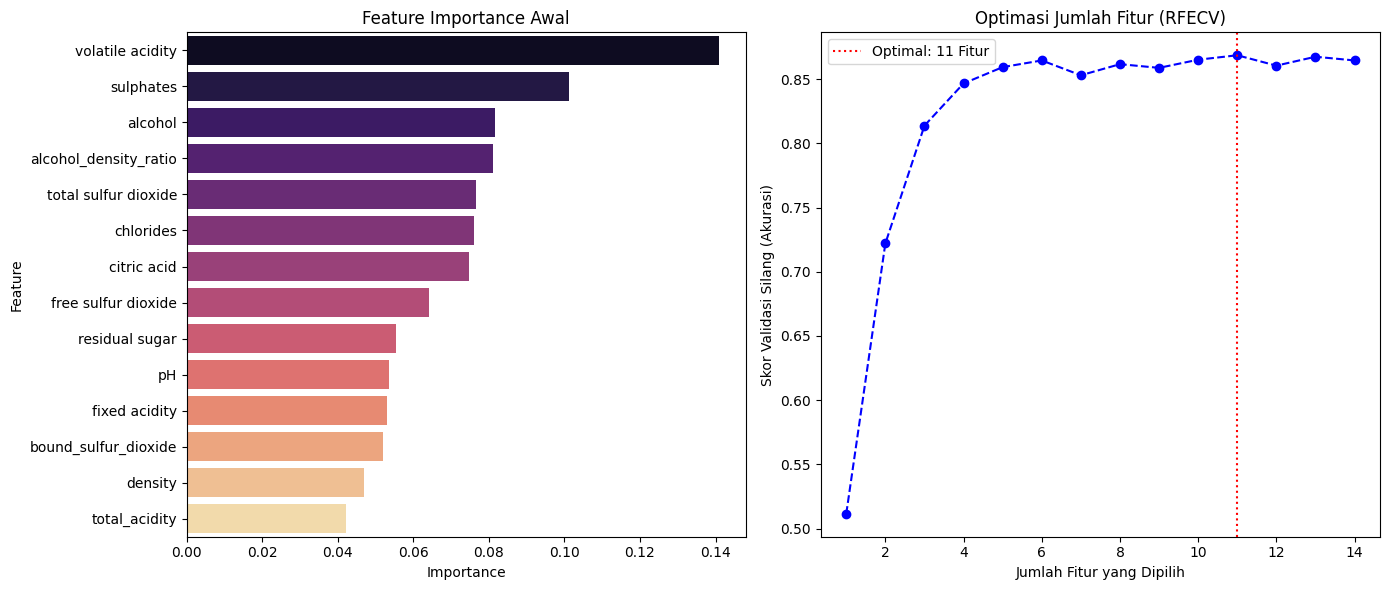


--- Hasil Eksekusi Pruning ---
Fitur yang dibuang: ['density', 'total_acidity', 'bound_sulfur_dioxide']
Fitur terpilih: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'alcohol_density_ratio']
Jumlah fitur akhir: 11


In [3]:
# =================================================================
# Tahap 3: Feature Engineering & Fitur Pruning (Revisi & Ditingkatkan)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 3.1 Menghitung Feature Importance Awal
# Menggunakan model dasar untuk melihat kontribusi fitur sebelum eliminasi
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_final, y_train_final)

feature_importance_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': rf_base.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3.2 Recursive Feature Elimination (RFECV)
# Mengotomatiskan pemilihan fitur berdasarkan performa validasi silang
print("--- Memulai Recursive Feature Elimination (RFECV) ---")
selector = RFECV(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    step=1,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
selector.fit(X_train_final, y_train_final)

# 3.3 Visualisasi Hasil Pruning Otomatis
plt.figure(figsize=(14, 6))

# Plot 1: Feature Importance (Original)
plt.subplot(1, 2, 1)
# Perbaikan FutureWarning: Menambahkan hue dan legend=False
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, 
            hue='Feature', palette='magma', legend=False)
plt.title('Feature Importance Awal')

# Plot 2: Performa Model vs Jumlah Fitur (Optimasi RFECV)
plt.subplot(1, 2, 2)
plt.xlabel("Jumlah Fitur yang Dipilih")
plt.ylabel("Skor Validasi Silang (Akurasi)")

# Perbaikan Error: Menggunakan len(cv_results_['mean_test_score'])
n_features_tried = len(selector.cv_results_['mean_test_score'])
plt.plot(range(1, n_features_tried + 1), selector.cv_results_['mean_test_score'], 
         marker='o', color='blue', linestyle='--')
plt.axvline(x=selector.n_features_, color='red', linestyle=':', label=f'Optimal: {selector.n_features_} Fitur')
plt.title('Optimasi Jumlah Fitur (RFECV)')
plt.legend()
plt.tight_layout()
plt.show()

# 3.4 Eksekusi Pruning Otomatis
# Mengambil daftar fitur yang dianggap optimal oleh RFECV
selected_features = X_train_final.columns[selector.support_].tolist()
dropped_features = [f for f in X_train_final.columns if f not in selected_features]

X_train_pruned = X_train_final[selected_features]
X_val_pruned = X_val_prepared[selected_features]
X_test_pruned = X_test_prepared[selected_features]

print(f"\n--- Hasil Eksekusi Pruning ---")
print(f"Fitur yang dibuang: {dropped_features}")
print(f"Fitur terpilih: {selected_features}")
print(f"Jumlah fitur akhir: {len(selected_features)}")

# Fitur Pruning

Fitur awal hasil RFECV: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'alcohol_density_ratio']


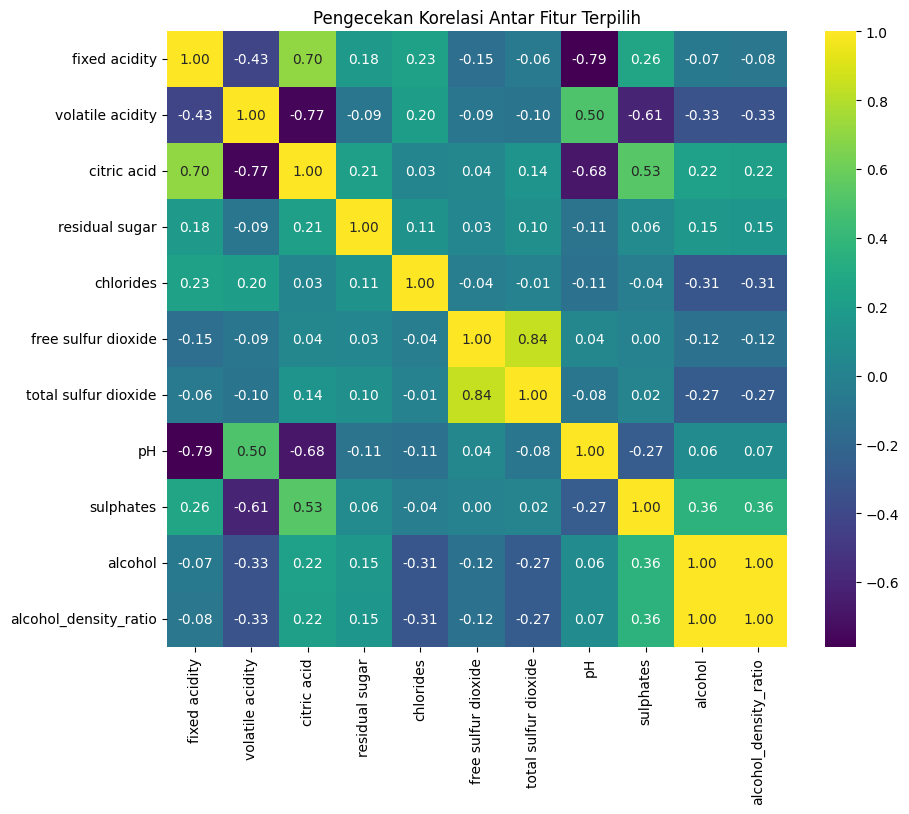


--- Ringkasan Final Fitur ---
Jumlah Fitur yang Digunakan: 11
Nama Fitur: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'alcohol_density_ratio']

Statistik Fitur Terpilih:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1734.0,0.032342,0.946666,-3.567776,-0.667250,0.009270,0.661113,2.755900
volatile acidity,1734.0,0.202708,1.257474,-2.862553,-0.931928,0.175899,1.246069,3.903599
citric acid,1734.0,-0.032110,1.079595,-1.541804,-1.208416,0.063430,0.948183,2.134312
residual sugar,1734.0,0.016359,0.941418,-5.354224,-0.635971,-0.040494,0.586349,2.674692
chlorides,1734.0,-0.163320,0.848112,-5.974139,-0.589151,-0.133239,0.203505,3.155383
free sulfur dioxide,1734.0,-0.347813,0.952468,-2.858888,-1.185176,-0.394701,0.365539,2.722468
total sulfur dioxide,1734.0,-0.441983,0.965542,-2.444025,-1.305255,-0.469677,0.314190,3.024174
pH,1734.0,0.081824,0.988346,-3.006454,-0.575992,0.043725,0.750305,3.781485
sulphates,1734.0,0.014848,0.957981,-2.756277,-0.625517,-0.080951,0.739651,3.075233
alcohol,1734.0,0.223270,0.973667,-2.411123,-0.544206,0.299420,1.052497,2.149532


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,alcohol_density_ratio
0,0.604634,1.377894,-0.042925,-1.174962,-0.033063,-0.420910,-0.816411,-0.146500,0.352995,-0.244168,-0.241974
1,-0.569616,1.110071,-1.190292,1.905588,0.336465,-1.600988,-1.685685,0.655032,-2.756277,0.658232,0.659507
2,-0.195547,-0.109587,0.063430,-0.635971,-0.934864,-0.568627,-0.270183,0.522486,0.133287,-0.775650,-0.764592
3,0.009270,-0.797989,0.924639,-0.635971,0.808160,-1.108916,-1.275308,-0.079125,0.133287,1.030665,1.032615
4,-0.414736,0.393348,-1.541804,-0.406668,-0.808685,-0.908930,-1.685685,0.918896,-0.369020,0.962060,0.964710


In [4]:
# =================================================================
# Tahap 4: Fitur Pruning & Finalisasi Data
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

# 4.1 Menerapkan Hasil RFECV (Otomatis)
# Kita mengambil daftar fitur yang sudah dibuktikan oleh mesin memberikan akurasi tertinggi
final_selected_features = selected_features # Variabel dari Tahap 3

print(f"Fitur awal hasil RFECV: {final_selected_features}")

# 4.2 Pengecekan Multikolinearitas (Opsional tetapi Disarankan)
# Terkadang fitur yang penting saling 'bertabrakan'. Kita cek korelasi antar fitur terpilih.
# Jika ada dua fitur yang korelasinya > 0.9, kita bisa buang salah satu untuk stabilitas model.
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_pruned.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Pengecekan Korelasi Antar Fitur Terpilih')
plt.show()

# 4.3 Finalisasi Dataset
# Menyiapkan variabel akhir yang akan digunakan untuk Optuna dan Pseudo-Labeling
X_train_final = X_train_pruned.copy()
X_val_final = X_val_pruned.copy()
X_test_final = X_test_pruned.copy()

# 4.4 Verifikasi Akhir Dimensi Data
print("\n--- Ringkasan Final Fitur ---")
print(f"Jumlah Fitur yang Digunakan: {X_train_final.shape[1]}")
print(f"Nama Fitur: {X_train_final.columns.tolist()}")

# Cek apakah ada data yang miring (skewed) yang tersisa
print("\nStatistik Fitur Terpilih:")
display(X_train_final.describe().T)

# Tampilkan data siap modeling
display(X_train_final.head())

# K-Fold Validation

--- Memulai Evaluasi Multi-Model (K-Fold) ---
RandomForest -> Accuracy: 0.8737 (+/- 0.0105), F1: 0.8707
ExtraTrees -> Accuracy: 0.8898 (+/- 0.0129), F1: 0.8871
XGBoost -> Accuracy: 0.8599 (+/- 0.0087), F1: 0.8562


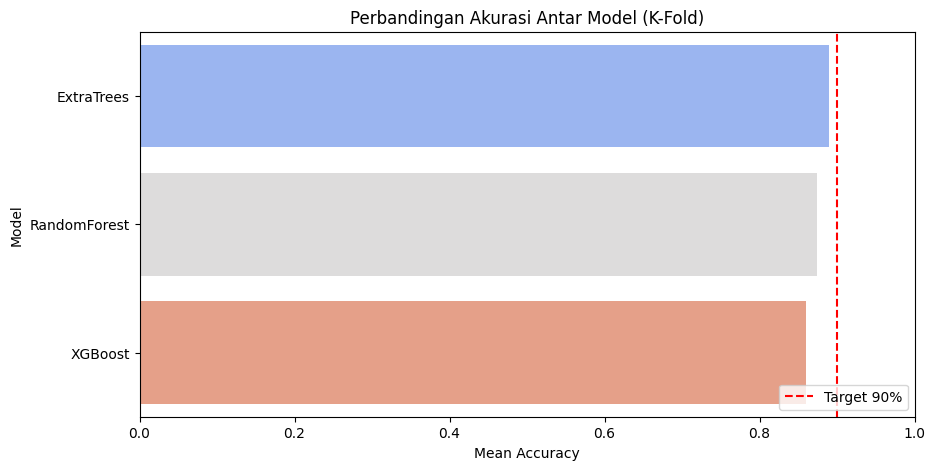


Model terbaik berdasarkan K-Fold: ExtraTrees
Gunakan model ini untuk tahap Tuning Optuna selanjutnya[cite: 1].


In [5]:
# =================================================================
# Tahap 5: K-Fold Validation (Revisi & Perbaikan Error)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 5.1 Inisialisasi Model
# Membandingkan model ensemble terbaik untuk data tabular.
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees': ExtraTreesClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# 5.2 Persiapan Label
# Memastikan label dimulai dari 0 agar kompatibel dengan XGBoost multi-class.
y_train_shifted = y_train_final - y_train_final.min()

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Memulai Evaluasi Multi-Model (K-Fold) ---")

for name, model in models.items():
    # Menggunakan metrik akurasi dan f1_weighted.
    cv_results = cross_validate(
        model, 
        X_train_final, 
        y_train_shifted, 
        cv=skf, 
        scoring=['accuracy', 'f1_weighted'],
        n_jobs=-1
    )
    
    # PERBAIKAN: Menambahkan awalan 'test_' pada akses key dictionary.
    mean_acc = cv_results['test_accuracy'].mean()
    std_acc = cv_results['test_accuracy'].std()
    mean_f1 = cv_results['test_f1_weighted'].mean()
    
    results.append({
        'Model': name,
        'Mean Accuracy': mean_acc,
        'Std Dev': std_acc,
        'Mean F1-Score': mean_f1
    })
    print(f"{name} -> Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f}), F1: {mean_f1:.4f}")

# 5.4 Visualisasi Perbandingan Model
results_df = pd.DataFrame(results).sort_values(by='Mean Accuracy', ascending=False)

plt.figure(figsize=(10, 5))
# Menghilangkan peringatan palette dengan menyertakan hue dan legend[cite: 1].
sns.barplot(x='Mean Accuracy', y='Model', data=results_df, hue='Model', palette='coolwarm', legend=False)
plt.axvline(x=0.9, color='red', linestyle='--', label='Target 90%')
plt.title('Perbandingan Akurasi Antar Model (K-Fold)')
plt.xlim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

# 5.5 Rekomendasi Model
best_model_name = results_df.iloc[0]['Model']
print(f"\nModel terbaik berdasarkan K-Fold: {best_model_name}")
print("Gunakan model ini untuk tahap Tuning Optuna selanjutnya[cite: 1].")

# Pseudo-Labeling

Jumlah sampel testing yang lolos ambang batas (>=0.9): 105


/tmp/ipykernel_16/2619884460.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_augmented, palette='magma')


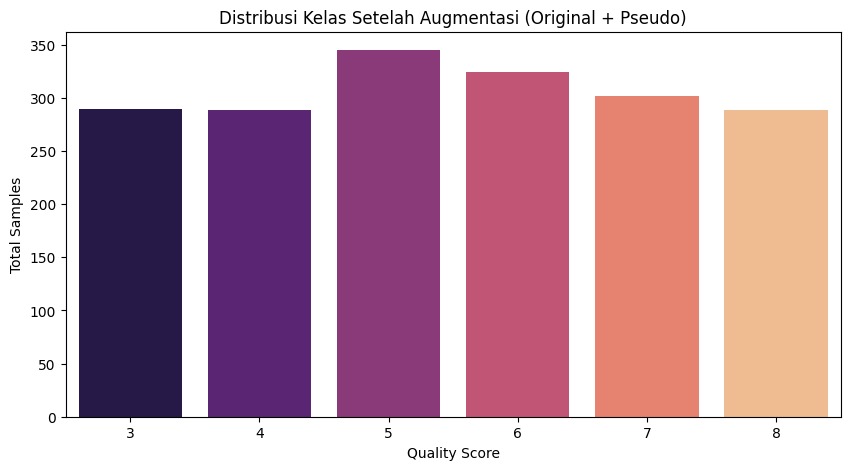

Total Data Training Baru: 1839

Distribusi Kualitas Baru:
3    290
4    289
5    345
6    324
7    302
8    289
Name: count, dtype: int64


In [6]:
# =================================================================
# Tahap 6: Pseudo-Labeling (Ditingkatkan)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Melatih Teacher Model (Gunakan Parameter Optimal/Terbaik)
# Kita geser label agar mulai dari 0 karena persyaratan XGBoost
min_label = y_train_final.min()
y_train_shifted = y_train_final - min_label

# Gunakan model terbaik hasil perbandingan Tahap 5 (Misal: XGBoost)
teacher_model = XGBClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42, 
    eval_metric='mlogloss'
)
teacher_model.fit(X_train_final, y_train_shifted)

# 6.2 Prediksi Probabilitas pada Data Testing
# Pastikan fitur pada data testing sama dengan data training
test_probs = teacher_model.predict_proba(X_test_final)
max_probs = np.max(test_probs, axis=1)
predicted_labels = np.argmax(test_probs, axis=1)

# 6.3 Menentukan Ambang Batas Kepercayaan yang Ketat
# Karena akurasi model dasar rendah, kita naikkan threshold ke 0.90 
# untuk memastikan hanya label yang 'pasti' benar yang masuk
confidence_threshold = 0.90 
high_confidence_idx = np.where(max_probs >= confidence_threshold)[0]

# 6.4 Membuat Dataset Pseudo-Labeled
# Ambil fitur dari data testing dan berikan label hasil tebakan model
X_pseudo = X_test_final.iloc[high_confidence_idx].copy()
y_pseudo = predicted_labels[high_confidence_idx] + min_label

print(f"Jumlah sampel testing yang lolos ambang batas (>={confidence_threshold}): {len(X_pseudo)}")

# 6.5 Menggabungkan Data dengan Reset Index
# Penting: Reset index untuk menghindari error saat pelatihan di tahap selanjutnya
X_train_augmented = pd.concat([X_train_final, X_pseudo], axis=0).reset_index(drop=True)
y_train_augmented = pd.concat([y_train_final, pd.Series(y_pseudo)], axis=0).reset_index(drop=True)

# 6.6 Visualisasi Hasil Augmentasi
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_augmented, palette='magma')
plt.title('Distribusi Kelas Setelah Augmentasi (Original + Pseudo)')
plt.xlabel('Quality Score')
plt.ylabel('Total Samples')
plt.show()

print(f"Total Data Training Baru: {X_train_augmented.shape[0]}")
print("\nDistribusi Kualitas Baru:")
print(y_train_augmented.value_counts().sort_index())

# Training Model dan Optuna 

In [7]:
!pip install optuna -q

In [8]:
# =================================================================
# Tahap 7: Training Model dan Optuna (Ditingkatkan)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# 7.1 Persiapan Label
min_label = y_train_augmented.min()
y_train_shifted = y_train_augmented - min_label

# 7.2 Definisikan Fungsi Objektif yang Lebih Agresif
def objective(trial):
    # Memperluas ruang pencarian termasuk regularisasi (alpha & lambda) 
    # untuk mencegah overfitting pada data kecil
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss'
    }
    
    model = XGBClassifier(**param)
    
    # Menggunakan cross_validate untuk memantau F1-Score dan Akurasi sekaligus
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(
        model, X_train_augmented, y_train_shifted, 
        cv=cv, 
        scoring='f1_weighted', # Optimasi pada F1 agar recall kelas minoritas naik
        n_jobs=-1
    )
    
    return cv_results['test_score'].mean()

# 7.3 Menjalankan Studi Optuna dengan Trial Lebih Banyak
print("--- Memulai Optimasi Hyperparameter (Target: F1-Weighted) ---")
study = optuna.create_study(direction='maximize')
# Menaikkan n_trials ke 100 untuk pencarian yang lebih teliti
study.optimize(objective, n_trials=100) 

print("\n--- Hasil Optimasi Terbaik ---")
print(f"Skor F1-Weighted Terbaik: {study.best_value:.4f}")
print("Parameter Terbaik untuk Akurasi Maksimal:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# 7.4 Melatih Model Final dengan Seluruh Data Augmented
final_params = study.best_params
final_params['random_state'] = 42
final_params['eval_metric'] = 'mlogloss'

final_model = XGBClassifier(**final_params)
final_model.fit(X_train_augmented, y_train_shifted)

print("\nModel Final Berhasil Dilatih dengan Parameter Optimal!")

[I 2026-05-02 16:24:10,355] A new study created in memory with name: no-name-2888980b-9bf7-4f3c-ac19-96dfd16e4532


--- Memulai Optimasi Hyperparameter (Target: F1-Weighted) ---


[I 2026-05-02 16:24:15,881] Trial 0 finished with value: 0.8572095061629984 and parameters: {'n_estimators': 1003, 'max_depth': 5, 'learning_rate': 0.09072792105538659, 'subsample': 0.7193665569267088, 'colsample_bytree': 0.8359834782467641, 'gamma': 2.846184940083448e-07, 'min_child_weight': 10, 'reg_alpha': 3.0894178859561667, 'reg_lambda': 0.00040999596857881873}. Best is trial 0 with value: 0.8572095061629984.
[I 2026-05-02 16:24:26,817] Trial 1 finished with value: 0.8590991589290281 and parameters: {'n_estimators': 478, 'max_depth': 9, 'learning_rate': 0.005479666399438299, 'subsample': 0.8924811605537961, 'colsample_bytree': 0.7943652546653468, 'gamma': 0.00020938514657740256, 'min_child_weight': 4, 'reg_alpha': 1.0838668899382134e-07, 'reg_lambda': 0.01456022338713111}. Best is trial 1 with value: 0.8590991589290281.
[I 2026-05-02 16:24:32,684] Trial 2 finished with value: 0.8634466279429999 and parameters: {'n_estimators': 752, 'max_depth': 5, 'learning_rate': 0.03784438897317


--- Hasil Optimasi Terbaik ---
Skor F1-Weighted Terbaik: 0.8777
Parameter Terbaik untuk Akurasi Maksimal:
  n_estimators: 656
  max_depth: 12
  learning_rate: 0.00790362276284521
  subsample: 0.7106895490996769
  colsample_bytree: 0.600842408823099
  gamma: 2.3449047943000021e-07
  min_child_weight: 1
  reg_alpha: 0.003892960304902078
  reg_lambda: 3.947885896003281e-06

Model Final Berhasil Dilatih dengan Parameter Optimal!


# Evaluasi Akhir 

--- RANGKUMAN EVALUASI FINAL ---
Akurasi Keseluruhan  : 57.56%
F1-Score (Weighted)  : 0.5723
F1-Score (Macro)     : 0.3620 (Keseimbangan performa antar kelas)

Classification Report Detail:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.71      0.69        73
           6       0.54      0.54      0.54        68
           7       0.47      0.41      0.44        22
           8       1.00      0.33      0.50         3

    accuracy                           0.58       172
   macro avg       0.45      0.33      0.36       172
weighted avg       0.58      0.58      0.57       172



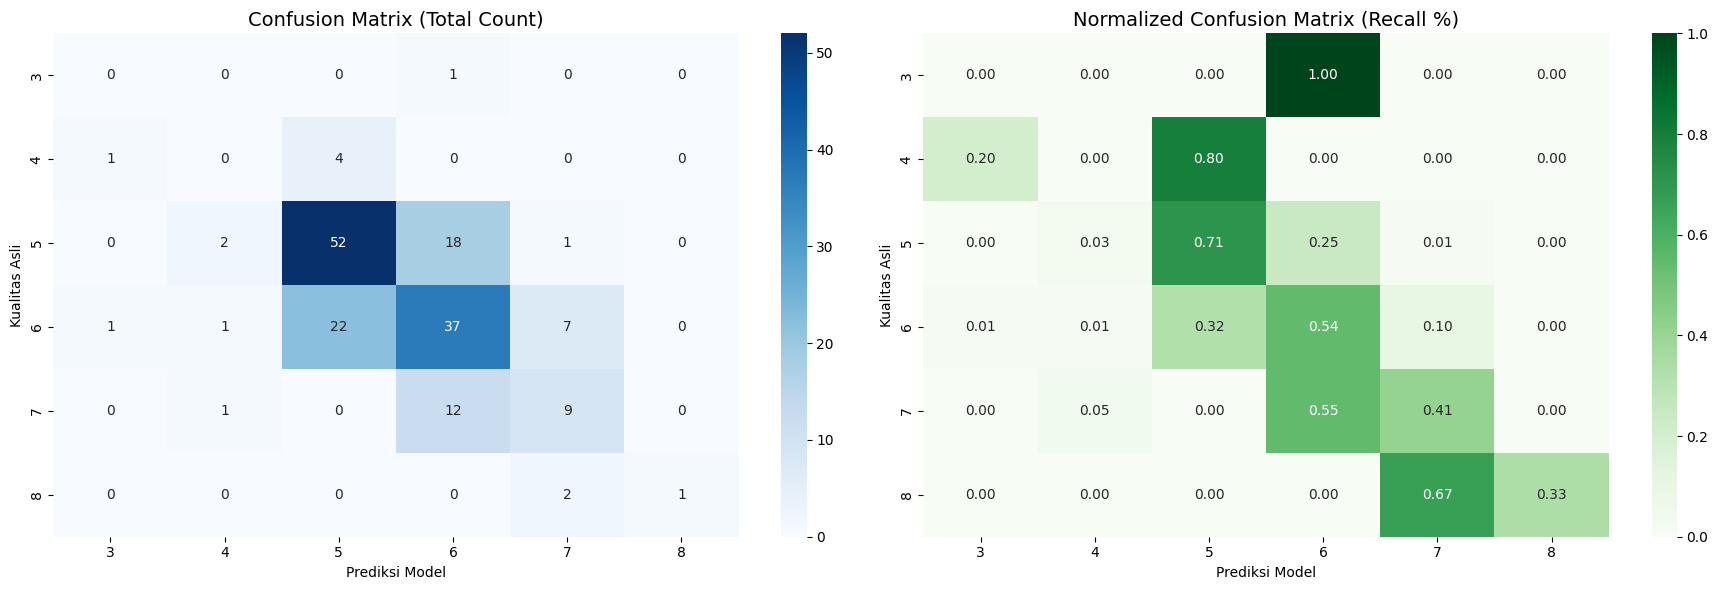

/tmp/ipykernel_16/3616864793.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


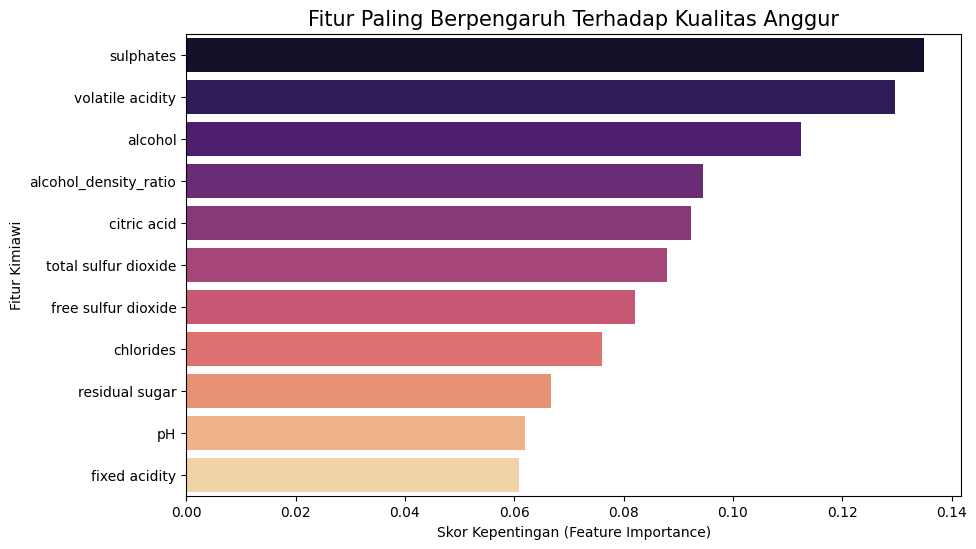

In [9]:
# =================================================================
# Tahap 8: Evaluasi Akhir (Ditingkatkan & Analisis Mendalam)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 8.1 Prediksi pada Data Validasi
# Menggunakan fitur yang sudah melewati tahap pruning dan pembersihan multikolinearitas
y_pred_val_shifted = final_model.predict(X_val_final)
y_pred_val = y_pred_val_shifted + min_label

# 8.2 Perhitungan Metrik Komprehensif
accuracy = accuracy_score(y_val, y_pred_val)
f1_weighted = f1_score(y_val, y_pred_val, average='weighted')
f1_macro = f1_score(y_val, y_pred_val, average='macro')

print(f"--- RANGKUMAN EVALUASI FINAL ---")
print(f"Akurasi Keseluruhan  : {accuracy * 100:.2f}%")
print(f"F1-Score (Weighted)  : {f1_weighted:.4f}")
print(f"F1-Score (Macro)     : {f1_macro:.4f} (Keseimbangan performa antar kelas)\n")

# 8.3 Classification Report Terperinci
print("Classification Report Detail:")
print(classification_report(y_val, y_pred_val, zero_division=0))

# 8.4 Visualisasi Confusion Matrix Ganda (Absolut & Normalisasi)
cm = confusion_matrix(y_val, y_pred_val)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] 
labels = sorted(y_val.unique())

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Jumlah Absolut (Count)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title('Confusion Matrix (Total Count)', fontsize=14)
ax[0].set_xlabel('Prediksi Model')
ax[0].set_ylabel('Kualitas Asli')

# Plot 2: Persentase (Normalized) - Melihat akurasi prediksi per skor kualitas
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=ax[1])
ax[1].set_title('Normalized Confusion Matrix (Recall %)', fontsize=14)
ax[1].set_xlabel('Prediksi Model')
ax[1].set_ylabel('Kualitas Asli')

plt.tight_layout()
plt.show()

# 8.5 Analisis Mendalam: Feature Importance[cite: 1]
# Melihat faktor kimiawi apa yang paling menentukan kualitas setelah optimasi
importances = final_model.feature_importances_
feature_names = X_train_final.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Fitur Paling Berpengaruh Terhadap Kualitas Anggur', fontsize=15)
plt.xlabel('Skor Kepentingan (Feature Importance)')
plt.ylabel('Fitur Kimiawi')
plt.show()

# Prediksi Data Uji (Testing)

--- PROSES SELESAI ---
File 'hasilprediksi_026.csv' berhasil dibuat untuk pengumpulan.
Total baris data uji: 286


/tmp/ipykernel_16/259990607.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=submission_df, palette='magma')


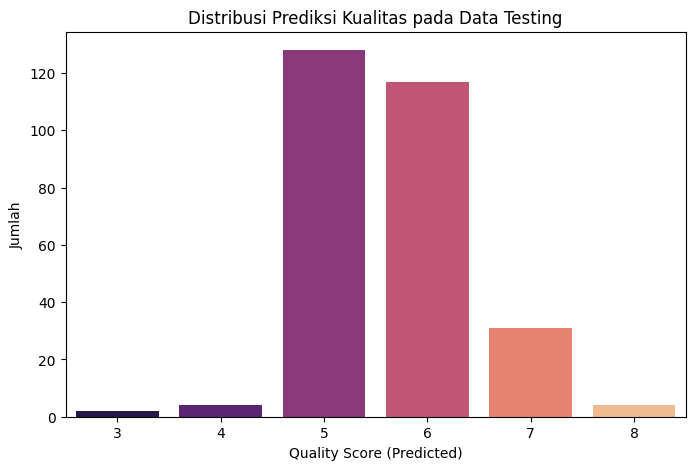


Contoh 5 baris pertama hasil prediksi:


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,7


In [10]:
# =================================================================
# Tahap 9: Prediksi Data Uji (Testing) - FINAL
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

# 9.1 Melakukan Prediksi pada Data Testing
# Menggunakan fitur yang sudah melewati tahap pruning sesuai model final
y_test_pred_shifted = final_model.predict(X_test_final)

# 9.2 Mengembalikan Skala Label (Reverse Shift)
# Mengembalikan label indeks 0 ke skala kualitas asli (misal: 3-8)
y_test_pred = y_test_pred_shifted + min_label

# 9.3 Membuat DataFrame Hasil Prediksi
# Pastikan tipe data 'quality' adalah integer agar sesuai format dataset asli
submission_df = pd.DataFrame({
    'Id': test_id,
    'quality': y_test_pred.astype(int)
})

# 9.4 Menyimpan Hasil ke File CSV
# Nama file diatur sesuai instruksi: hasilprediksi_3digitNIMterakhir.csv
file_output = 'hasilprediksi_026.csv'
# File hanya memuat 2 variabel: id dan quality
submission_df.to_csv(file_output, index=False)

print(f"--- PROSES SELESAI ---")
print(f"File '{file_output}' berhasil dibuat untuk pengumpulan.")
print(f"Total baris data uji: {len(submission_df)}")

# 9.5 Visualisasi Distribusi Prediksi
# Berguna untuk mengecek apakah model memprediksi variasi kualitas yang cukup
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=submission_df, palette='magma')
plt.title('Distribusi Prediksi Kualitas pada Data Testing')
plt.xlabel('Quality Score (Predicted)')
plt.ylabel('Jumlah')
plt.show()

# 9.6 Verifikasi Akhir Format
print("\nContoh 5 baris pertama hasil prediksi:")
display(submission_df.head())